In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix




In [53]:
#Load Data Set

data = load_breast_cancer()

x = pd.DataFrame(
    data.data,
    columns = data.feature_names
)

y = pd.Series((data.target == 0).astype(int), name = "malignant")

print(y.value_counts())

print("Feature matrix shape: ", x.shape)
print("Target shape: ", y.shape)
print("Class names: ", data.target_names)


malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape:  (569, 30)
Target shape:  (569,)
Class names:  ['malignant' 'benign']


In [54]:
#examine the class distribution

class_counts = y.value_counts().sort_index()
class_distrbtion =  pd.DataFrame({
    "Class": data.target_names,
    "Count": class_counts.values,
    "Probability": class_counts.values / len(y)
})

print(class_distrbtion)

       Class  Count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


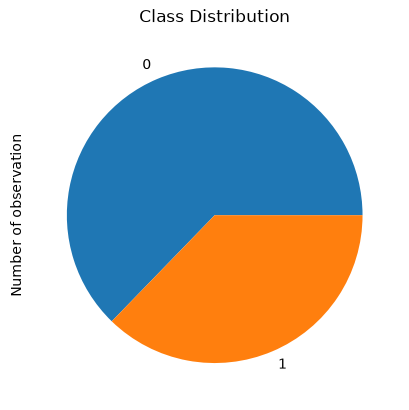

In [55]:
#ploting data using label

class_distrbtion.plot(
    x = "Class",
    y = "Count",
    kind = "pie",
    legend= False,
    color = ["green", "black"]
)

plt.ylabel("Number of observation")
plt.title("Class Distribution")
plt.xticks(rotation = 0)
plt.show()




In [56]:
#Create training and testing sample

x_train,  x_test,y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    stratify=y
)

print("Training Size:", len(y_train))
print("Testing Size:", len(y_test))

print("\nTraining Propostions: ")
print(y_train.value_counts(normalize = True).sort_index())

print("\nTesting Propostions: ")
print(y_test.value_counts(normalize = True).sort_index())


Training Size: 455
Testing Size: 114

Training Propostions: 
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing Propostions: 
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [57]:
#Train a logistic regression model

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [58]:
# Prediction
y_pred = model.predict(x_test)

# Results
print("Predicted values:", y_pred)
print("Actual values:", y_test.values)

Predicted values: [0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1
 1 0 0]
Actual values: [0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1
 1 0 0]


In [59]:
#obtain predict probilities

proablities = model.predict_proba(x_test)

print(proablities[:5])

[[9.99949475e-01 5.05250988e-05]
 [5.95852636e-04 9.99404147e-01]
 [9.99916209e-01 8.37907086e-05]
 [9.94515578e-01 5.48442223e-03]
 [9.98880569e-01 1.11943138e-03]]


In [60]:
print(proablities[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [61]:
results = pd.DataFrame({
    "Actual class": y_test.values,
    "P_malignant": proablities[:, 0],
    "P_Benign": proablities[:, 1]
})

results


,Actual class,P_malignant,P_Benign
0,0,9.999495e-01,0.000051
1,1,5.958526e-04,0.999404
2,0,9.999162e-01,0.000084
3,0,9.945156e-01,0.005484
4,0,9.988806e-01,0.001119
...,...,...,...
109,1,4.394396e-03,0.995606
110,1,2.093030e-08,1.000000
111,1,2.766559e-05,0.999972
112,0,9.999008e-01,0.000099


In [62]:
print(results.head())
print(results.columns)


   Actual class  P_malignant  P_Benign
0             0     0.999949  0.000051
1             1     0.000596  0.999404
2             0     0.999916  0.000084
3             0     0.994516  0.005484
4             0     0.998881  0.001119
Index(['Actual class', 'P_malignant', 'P_Benign'], dtype='str')


In [63]:
results["Actual Labels"] = results["Actual class"].map({
    0: "P_malignant",
    1: "P_Benign"
})

print(
    results[
        ["Actual Labels", "P_malignant", "P_Benign"]
    ].head(10)
)



  Actual Labels   P_malignant  P_Benign
0   P_malignant  9.999495e-01  0.000051
1      P_Benign  5.958526e-04  0.999404
2   P_malignant  9.999162e-01  0.000084
3   P_malignant  9.945156e-01  0.005484
4   P_malignant  9.988806e-01  0.001119
5      P_Benign  8.765055e-09  1.000000
6   P_malignant  9.999946e-01  0.000005
7   P_malignant  9.999140e-01  0.000086
8      P_Benign  1.513118e-02  0.984869
9      P_Benign  8.491282e-06  0.999992


In [64]:
threshold = 0.50

results["Predicted_mal"] = (
    results["P_malignant"] >= threshold
).astype(int)


results["Predicted Labels"] = results[
    "Predicted_mal"
].map({
    1: "P_malignant",
    0: "P_Benign"
})

print(
    results[
        [
            "Actual Labels",
            "P_malignant",
            "Predicted Labels"

        ]
    ]
)

    Actual Labels   P_malignant Predicted Labels
0     P_malignant  9.999495e-01      P_malignant
1        P_Benign  5.958526e-04         P_Benign
2     P_malignant  9.999162e-01      P_malignant
3     P_malignant  9.945156e-01      P_malignant
4     P_malignant  9.988806e-01      P_malignant
..            ...           ...              ...
109      P_Benign  4.394396e-03         P_Benign
110      P_Benign  2.093030e-08         P_Benign
111      P_Benign  2.766559e-05         P_Benign
112   P_malignant  9.999008e-01      P_malignant
113   P_malignant  9.617136e-01      P_malignant

[114 rows x 3 columns]


In [65]:
for threshold in [0.30, 0.50, 0.70]:
    predictions = (
        results["P_malignant"] >= threshold
    ).astype(int)

    print(
        f"Threshold = (threshold): ""LabWork 1108.ipynb"
        f"Predicted malignant cases: = {predictions.sum()}" 
    )

Threshold = (threshold): LabWork 1108.ipynbPredicted malignant cases: = 80
Threshold = (threshold): LabWork 1108.ipynbPredicted malignant cases: = 76
Threshold = (threshold): LabWork 1108.ipynbPredicted malignant cases: = 73


In [66]:
#construct a confusion matrix

actual_mali = (y_test.values == 0).astype(int)

for threshold in [0.30, 0.50,0.70]:
    pred_mal = (
        proablities[:,0] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        actual_mali, 
        pred_mal
    )

    print(f"\nThreshold = {threshold}")
    print(cm)


# TP - Mal - Mal
# FP - Ben - Mal
# FN - Mal - Ben 
# TN - Ben - Ben


Threshold = 0.3
[[34  8]
 [ 0 72]]

Threshold = 0.5
[[38  4]
 [ 0 72]]

Threshold = 0.7
[[40  2]
 [ 1 71]]


Accuracy: The percentage of total predictions that are correct.

    → Formula: (TP + TN) / (TP + TN + FP + FN)

Precision: Out of all the cases the model predicted as positive, how many were actually positive.

    → Formula: TP / (TP + FP)
    
    → “When the model says positive, how often is it right?”

Recall: Out of all the cases that were actually positive, how many did the model correctly identify.
    
    →Formula: TP / (TP + FN)
    
    → “How many of the actual positives did the model find?”

F1-score: The harmonic mean of precision and recall, giving a single score that balances both.  
    
    →Formula: 2 × (Precision × Recall) / (Precision + Recall)
    
    → Useful when you want a balance between missing positives and producing false positives.

In [67]:
#verifying above things

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
y_pred = pred_mal

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ", accuracy)

print("Precision Score: ", precision)

print("Recall Score: ", recall)

print("F1 Score: ", f1)

Accuracy:  0.02631578947368421
Precision Score:  0.0273972602739726
Recall Score:  0.047619047619047616
F1 Score:  0.034782608695652174


In [68]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

result = []
y_prob = model.predict_proba(x_test)[:, 1]
for thresholld in [0.1,0.30, 0.50, 0.70, 0.9]:
    y_pred = (y_prob >= thresholld).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        "Threshold": thresholld,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

result_table = pd.DataFrame(result)

result_table

,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1 Score
0,0.1,42,70,2,0,0.982456,0.954545,1.000000,0.976744
1,0.3,40,71,1,2,0.973684,0.975610,0.952381,0.963855
2,0.5,38,72,0,4,0.964912,1.000000,0.904762,0.950000
3,0.7,34,72,0,8,0.929825,1.000000,0.809524,0.894737
4,0.9,33,72,0,9,0.921053,1.000000,0.785714,0.880000
